In [1]:
import os                    
import matplotlib           
import matplotlib.pyplot as plt
import numpy as np            
import astropy.io.fits       
import astropy.coordinates   
import fitsio               
import sdss_access          
from astropy.coordinates import SkyCoord
import astropy.units as u

matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.size'] = 14

url_root = 'https://data.sdss.org/sas'
local_root = os.getenv('SAS_BASE_DIR')

sdss_path = sdss_access.path.Path(release='dr19', verbose=True)

In [2]:
# from lab04
sdss_path = sdss_access.path.Path(release='dr19', verbose=True)
access = sdss_access.Access(release='dr19', verbose=True)

allspec_file = sdss_path.full('allspec', vers='1.0.1', release='dr19')

if not sdss_path.exists('', full=allspec_file):
    access.remote()
    access.add('allspec', vers='1.0.1', release='dr19')
    access.set_stream()
    access.commit()

allspec_hdus = astropy.io.fits.open(allspec_file)
allspec = np.array(allspec_hdus[1].data)

In [3]:
# Just to see
print(allspec.dtype.names)

('allspec_id', 'multiplex_id', 'sdss_phase', 'observatory', 'instrument', 'sdss_id', 'catalogid', 'fiberid', 'ifudsgn', 'plate', 'fps_field', 'plate_or_fps_field', 'mjd', 'run2d', 'run1d', 'coadd', 'apred_vers', 'drpver', 'version', 'programname', 'survey', 'sas_file', 'cas_url', 'sas_url', 'ra', 'dec', 'healpix', 'healpixgrp', 'apogee_id', 'apogee_field', 'telescope', 'file_spec', 'apstar_id', 'visit_id', 'mangaid', 'specobjid')


In [4]:
# troubleshoot
print(len(unique_ra), len(unique_dec))
print(np.sum(np.isfinite(unique_ra)), np.sum(np.isfinite(unique_dec)))
print(unique_ra[:10], unique_dec[:10])


[ERROR]: Traceback (most recent call last):
  File "/home/idies/mambaforge/envs/py39/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3433, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_237/3266071148.py", line 2, in <module>
    print(len(unique_ra), len(unique_dec))
NameError: name 'unique_ra' is not defined



In [4]:
# Lab04 code mod

# Jason's quasar coordinates
ra_jason = 213.351149549
dec_jason = 53.090819798

target = SkyCoord(ra_jason*u.deg, dec_jason*u.deg) # target location

# Extract unique objects from allspec (all lowercase here)
unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

mask = np.isfinite(unique_ra) & np.isfinite(unique_dec) #np.isfinite from APPM2360 project 2
# np.isfinite https://medium.com/@whyamit404/understanding-numpy-isfinite-with-examples-7305ff609ce9 

# update unique_ra and unique_dec with only usable numbers
unique_ra = unique_ra[mask]
unique_dec = unique_dec[mask]
unique_sdss_id = unique_sdss_id[mask]

# indx, sep, s3 = unique_coords.match_to_catalog_sky(center_coords) except I don't wnat to center them I want the exact target to match my unique_coord 
unique_coords = SkyCoord(unique_ra, unique_dec, unit='deg') # this is where units='deg' comes in
indx, sep, _ = target.match_to_catalog_sky(unique_coords) # I use "_" becasue the variable is temporary and mostly a placeholder
#Find an ID for this quasar so I don't have to rmember Ra/Dec
jason_sdss_id = unique_sdss_id[indx] # Maybe we can use this in Sky server?
print("Jason's SDSS-V ID:", jason_sdss_id)
print("Angular separation (arcsec):", sep.to(u.arcsec).value)


Jason's SDSS-V ID: 62239511
Angular separation (arcsec): [0.07615622]


In [17]:
#Kelly's code
# New coordinates to test
target_ra_4 = 36.730377  
target_dec_4 = 1.117010
tolerance = 0.0005

# Search the master index
mask_4 = (np.abs(allspec['ra'] - target_ra_4) < tolerance) & \
         (np.abs(allspec['dec'] - target_dec_4) < tolerance)

epoch_count_4 = np.sum(mask_4)

print(f"Target: RA {target_ra_4}, Dec {target_dec_4}")
print(f"Number of Epochs found: {epoch_count_4}")

if epoch_count_4 > 20:
    print("Verdict: This is a high-density target! Worth investigating.")
else:
    print("Verdict: Still in the low-count zone. The search continues!")
    
    
  

Target: RA 36.730377, Dec 1.11701
Number of Epochs found: 19
Verdict: Still in the low-count zone. The search continues!


In [27]:
#Kelly's code
# New coordinates to test
target_ra_4 = 333.893768       
target_dec_4 = 0.356651       
tolerance = 0.0005

# Search the master index
mask_4 = (np.abs(allspec['ra'] - target_ra_4) < tolerance) & \
         (np.abs(allspec['dec'] - target_dec_4) < tolerance)

epoch_count_4 = np.sum(mask_4)

print(f"Target: RA {target_ra_4}, Dec {target_dec_4}")
print(f"Number of Epochs found: {epoch_count_4}")

if epoch_count_4 > 20:
    print("Verdict: This is a high-density target! Worth investigating.")
else:
    print("Verdict: Still in the low-count zone. The search continues!")
    
    
  

Target: RA 333.893768, Dec 0.356651
Number of Epochs found: 25
Verdict: This is a high-density target! Worth investigating.


In [ ]:
#Kelly's code
# New coordinates to test
target_ra_4 = 333.893768       
target_dec_4 = 0.356651       
tolerance = 0.0005

# Search the master index
mask_4 = (np.abs(allspec['ra'] - target_ra_4) < tolerance) & \
         (np.abs(allspec['dec'] - target_dec_4) < tolerance)

epoch_count_4 = np.sum(mask_4)

print(f"Target: RA {target_ra_4}, Dec {target_dec_4}")
print(f"Number of Epochs found: {epoch_count_4}")

if epoch_count_4 > 20:
    print("Verdict: This is a high-density target! Worth investigating.")
else:
    print("Verdict: Still in the low-count zone. The search continues!")


In [70]:
# check how mny visits this quasar has (hopefully a lot)
jason_rows = allspec[allspec['sdss_id'] == jason_sdss_id]
# If I print the length of rows for this quasar it should tell me how many times it is in the d19 allspec dataset which is really the number of epochs it has.
print("Number of epochs:", len(jason_rows))

Number of epochs: 175


In [72]:
# Now that we know there are multiple visits we can pull the data from those visits to start analyzing the spectra
spectra = []

for row in jason_rows:
    # I was getting an error something about bytes not str???
    sas_url = row['sas_url'].decode()
    local_path = sas_url.replace(url_root, local_root)

    # From lab04 and others 
    if not os.path.exists(local_path):
        access.remote()
        access.add(row['sas_url']) #line of error?
        access.set_stream()
        access.commit()

    # open the FITS file
    hdul = astropy.io.fits.open(local_path)
    data = hdul[1].data

    wavelength = 10**data['loglam']
    flux = data['flux']
    mjd = row['mjd']

    spectra.append({
        "wavelength": wavelength,
        "flux": flux,
        "mjd": mjd
    })
hdul

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7f2e343ae8e0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7f2e2d38f910>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7f2e301f7340>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7f2e2d0ed9a0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7f33784849a0>]

In [7]:
# Allspec does not have z specs so I should load in spall
# Load spAll Like in lab04 and others
spall_file = sdss_path.full('spAll', run2d='v6_1_3')

if not sdss_path.exists('', full=spall_file):
    access.remote()
    access.add('spAll', run2d='v6_1_3')
    access.set_stream()
    access.commit()

print("spAll file:", spall_file)

# Not alspec anymore -> spall uses all CAPS!
spall_columns = [
    'SDSS_ID', 'CARTON_TO_TARGET_PK', 'MJD', 'CLASS', 'SUBCLASS',
    'Z', 'ZWARNING', 'SN_MEDIAN_ALL', 'PSFMAG', 'SPEC_FILE',
    'HEALPIX_PATH', 'OBJTYPE'
]

spall = fitsio.read(spall_file, columns=spall_columns)

spAll file: /home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spAll-v6_1_3.fits.gz


In [8]:
# hopefully I can find Jason's quasar in spall. I will also need to get Z from spall
jason_spall_rows = spall[spall['SDSS_ID'] == jason_sdss_id]
print(jason_spall_rows['Z'])

[0.45688647 0.45711648 0.4567876  0.45655227 0.456943   0.4564387
 0.45669004 0.4563893  0.45656264 0.45643416 0.45640764 0.45660305
 0.45649126 0.45653963 0.45689335 0.45648324 0.45634452 0.45623776
 0.45623776 0.45621565 0.45628324 0.45627546 0.4562167  0.45625433
 0.4562791  0.45619053 0.45632657 0.45625818 0.4562084  0.45619023
 0.45618832 0.4562987  0.45626912 0.4561884  0.45629737 0.45607868
 0.45628032 0.45622888 0.45640412 0.45617735 0.4560808  0.4562389
 0.4562289  0.4561935  0.45623934 0.45610085 0.45630583 0.4562312
 0.45615867 0.4562008  0.45620018 0.45628622 0.4563063  0.45609593
 0.4561656  0.45616573]


In [13]:
max(fl[mask])
spectra_cut = spectra[::15]
spectra_cut

[{'wavelength': array([3794.8972, 3795.7703, 3796.6455, ..., 9187.558 , 9189.672 ,
         9191.785 ], dtype=float32),
  'flux': array([5.6278777, 3.385206 , 1.1439179, ..., 3.4513402, 3.9906595,
         4.0081673], dtype='>f4'),
  'mjd': 52762},
 {'wavelength': array([ 3612.435 ,  3613.266 ,  3614.0994, ..., 10332.376 , 10334.747 ,
         10337.131 ], dtype=float32),
  'flux': array([30.736898 ,  3.6056588, 32.966946 , ...,  6.1433783,  4.4017687,
          2.660123 ], dtype='>f4'),
  'mjd': 57805},
 {'wavelength': array([ 3607.447 ,  3608.2788,  3609.109 , ..., 10387.236 , 10389.631 ,
         10392.016 ], dtype=float32),
  'flux': array([18.774582 ,  6.549503 ,  3.7700355, ..., 19.326275 ,  7.532473 ,
         -4.261611 ], dtype='>f4'),
  'mjd': 56739},
 {'wavelength': array([ 3612.435 ,  3613.266 ,  3614.0994, ..., 10375.279 , 10377.672 ,
         10380.064 ], dtype=float32),
  'flux': array([16.530159 ,  3.579511 ,  7.2728157, ...,  5.32951  ,  4.290879 ,
          3.2522106],

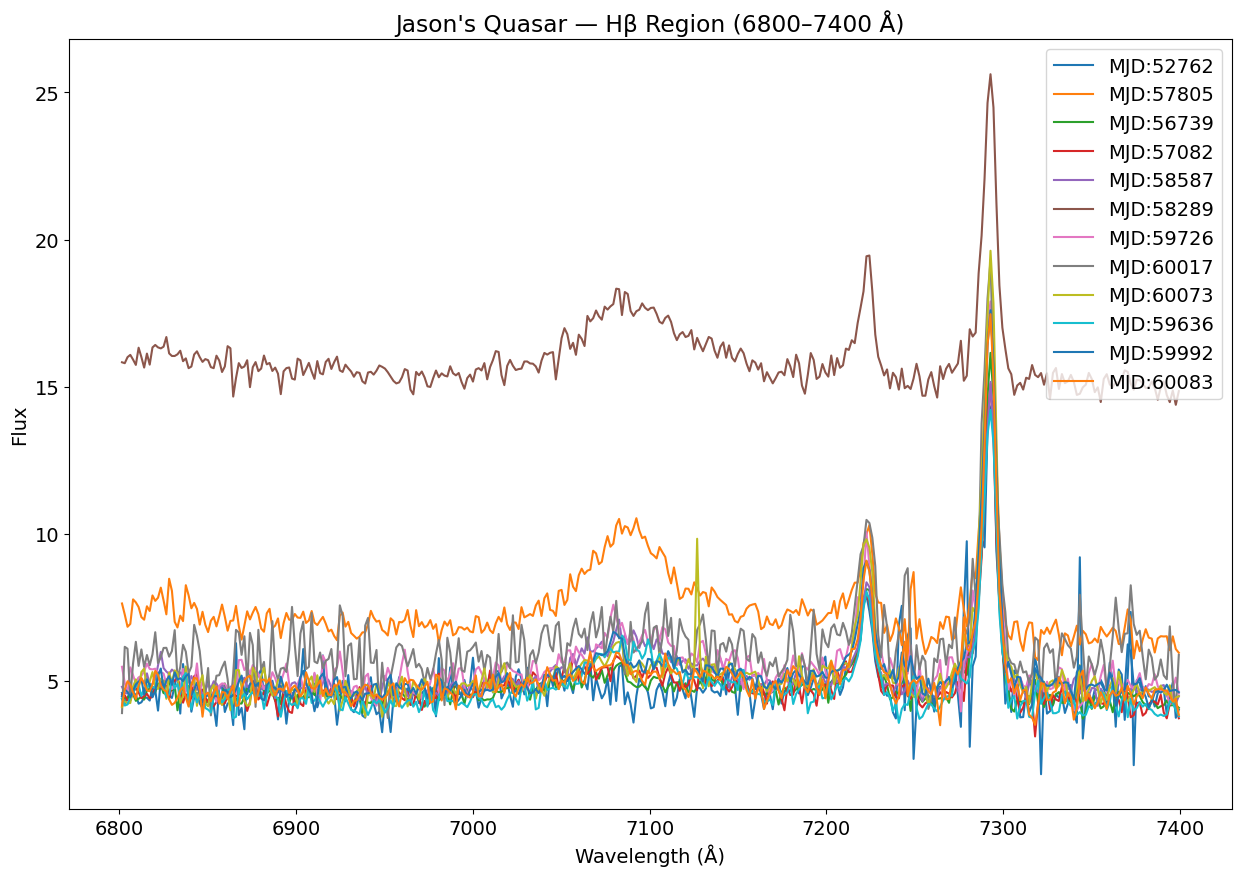

In [14]:
plt.rcParams['figure.figsize'] = [15, 10] # I remember needing something liek this. It will error otherwise
for s in spectra_cut:
    wl = s["wavelength"]
    fl = s["flux"]

    mask = (wl > 6800) & (wl < 7400)
    plt.plot(wl[mask], fl[mask], label=f'MJD:{s["mjd"]}' )


plt.legend()
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Jason's Quasar — Hβ Region (6800–7400 Å)")
plt.show();

# These are the BLR plots 

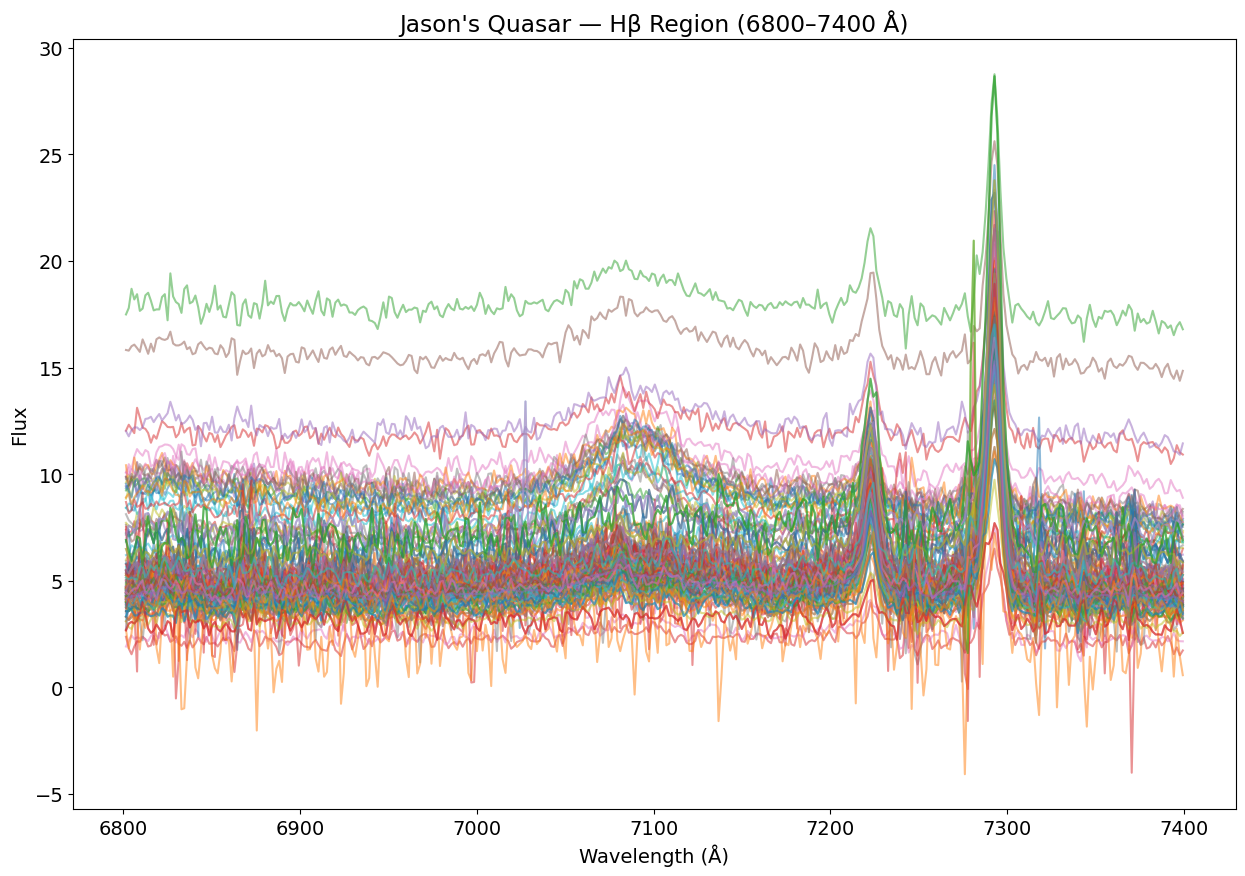

In [24]:
max_flux = []

matplotlib.rcParams['text.usetex'] = False # I remember needing something liek this. It will error otherwise
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask = (wl > 6800) & (wl < 7400)
    max_flux.append(max(fl[mask]))
    plt.plot(wl[mask], fl[mask], alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Jason's Quasar — Hβ Region (6800–7400 Å)")
plt.show();

# These are the BLR plots 

In [ ]:
matplotlib.rcParams['text.usetex'] = False # I remember needing something like this. It will error otherwise
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask = (wl > 6800) & (wl < 7400)
    plt.plot(wl[mask], fl[mask], alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Jason's Quasar — Hβ Region (6800–7400 Å)")
plt.legend()
plt.show();

# These are the BLR plots 

Next steps: Random code ideas for plots

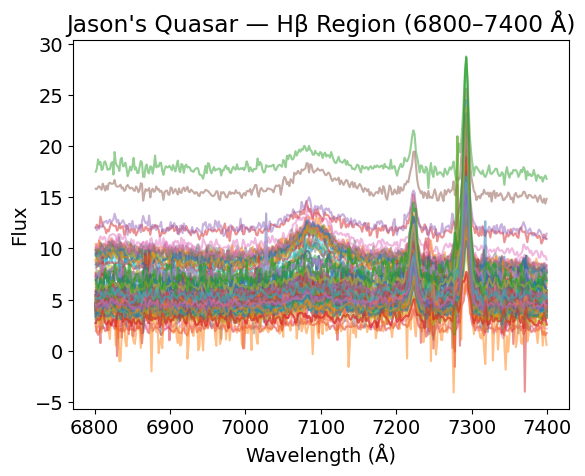

In [34]:
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask = (wl > 6800) & (wl < 7400)
    plt.plot(wl[mask], fl[mask], alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Jason's Quasar — Hβ Region (6800–7400 Å)")
plt.show();


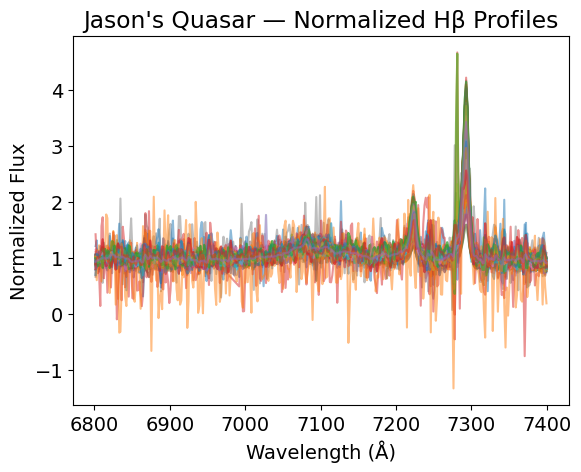

In [35]:
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask = (wl > 6800) & (wl < 7400)
    wl_zoom = wl[mask]
    fl_zoom = fl[mask]

    # continuum = median of left edge
    cont = np.nanmedian(fl_zoom[(wl_zoom > 6800) & (wl_zoom < 6850)])
    plt.plot(wl_zoom, fl_zoom/cont, alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title("Jason's Quasar — Normalized Hβ Profiles")
plt.show();


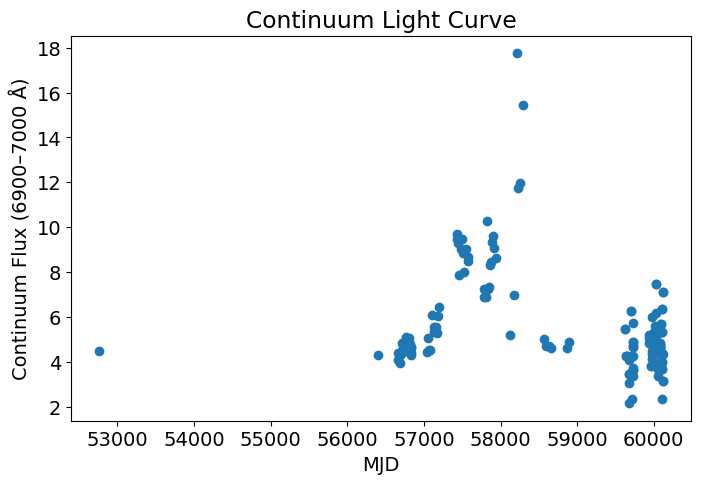

4.3480654


In [46]:
def continuum_flux(wl, fl, lam_min, lam_max):
    mask = (wl > lam_min) & (wl < lam_max)
    return np.nanmedian(fl[mask])

cont_times = []
cont_values = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f = continuum_flux(wl, fl, 6900, 7000)  # clean continuum values?
    cont_times.append(mjd)
    cont_values.append(f)

plt.figure(figsize=(8,5))
plt.scatter(cont_times, cont_values)
plt.xlabel("MJD")
plt.ylabel("Continuum Flux (6900–7000 Å)")
plt.title("Continuum Light Curve")
plt.show()


In [29]:
def line_flux(wl, fl, center, width=40):
    lam_min = center - width
    lam_max = center + width

    mask = (wl > lam_min) & (wl < lam_max)

    # continuum from edges
    cont_mask = ((wl > lam_min) & (wl < lam_min+10)) | \
                ((wl < lam_max) & (wl > lam_max-10))
    cont = np.nanmedian(fl[cont_mask])

    return np.trapz(fl[mask] - cont, wl[mask])

hb_center = 4861 * (1 + z_jason)

hb_times = []
hb_values = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f = line_flux(wl, fl, hb_center)
    hb_times.append(mjd)
    hb_values.append(f)

plt.figure(figsize=(8,5))
plt.scatter(hb_times, hb_values)
plt.xlabel("MJD")
plt.ylabel("Hβ Line Flux")
plt.title("Hβ Light Curve")
plt.show()


[ERROR]: Traceback (most recent call last):
  File "/home/idies/mambaforge/envs/py39/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3433, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_87/2139753516.py", line 14, in <module>
    hb_center = 4861 * (1 + z_jason)
NameError: name 'z_jason' is not defined



In [30]:
plt.figure(figsize=(6,6))
plt.scatter(cont_values, hb_values)
plt.xlabel("Continuum Flux")
plt.ylabel("Hβ Line Flux")
plt.title("BLR Response to Disk Variability")
plt.show()


[ERROR]: Traceback (most recent call last):
  File "/home/idies/mambaforge/envs/py39/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3433, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_87/432358661.py", line 2, in <module>
    plt.scatter(cont_values, hb_values)
NameError: name 'hb_values' is not defined



<Figure size 600x600 with 0 Axes>

In [36]:
# pick bright and faint epochs
i_bright = np.argmax(cont_values)
i_faint = np.argmin(cont_values)

wl_b = spectra[i_bright]["wavelength"]
fl_b = spectra[i_bright]["flux"]

wl_f = spectra[i_faint]["wavelength"]
fl_f = spectra[i_faint]["flux"]

# interpolate faint spectrum onto bright wavelength grid
fl_f_interp = np.interp(wl_b, wl_f, fl_f)

# zoom region
mask = (wl_b > 6800) & (wl_b < 7400)

plt.figure(figsize=(10,6))
plt.plot(wl_b[mask], fl_b[mask] - fl_f_interp[mask])
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux Difference")
plt.title("Difference Spectrum (Bright - Faint)")
plt.show()


[ERROR]: Traceback (most recent call last):
  File "/home/idies/mambaforge/envs/py39/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3433, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_658/1945417779.py", line 2, in <module>
    i_bright = np.argmax(cont_values)
NameError: name 'cont_values' is not defined



In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

mjds = np.array([s["mjd"] for s in spectra])
norm = plt.Normalize(mjds.min(), mjds.max())
cmap = plt.cm.viridis

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mask = (wl > 6800) & (wl < 7400)
    ax.plot(wl[mask], fl[mask], color=cmap(norm(s["mjd"])), alpha=0.6)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax, label="MJD")

ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("Flux")
ax.set_title("Time‑Colored Hβ Evolution")

plt.show()


Covariance table

In [31]:
cont_arr = np.array(cont_values)
hb_arr   = np.array(hb_values)


[ERROR]: Traceback (most recent call last):
  File "/home/idies/mambaforge/envs/py39/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3433, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_87/3894959431.py", line 2, in <module>
    hb_arr   = np.array(hb_values)
NameError: name 'hb_values' is not defined



In [ ]:
cov_matrix = np.cov(np.vstack([cont_arr, hb_arr]))
print("Covariance matrix:")
print(cov_matrix)


In [ ]:
labels = ["Continuum", "Hβ line"]

print("Covariance table:")
for i in range(2):
    for j in range(2):
        print(f"Cov({labels[i]}, {labels[j]}) = {cov_matrix[i, j]:.3e}")


In [ ]:
corr_matrix = np.corrcoef(np.vstack([cont_arr, hb_arr]))
print("Correlation matrix:")
print(corr_matrix)


In [ ]:
print("Correlation table:")
for i in range(2):
    for j in range(2):
        print(f"Corr({labels[i]}, {labels[j]}) = {corr_matrix[i, j]:.3f}")


Summary

In [25]:
print(max_flux)

[14.519897, 15.7602825, 16.044199, 15.665455, 15.672176, 15.965437, 14.414433, 17.201572, 15.3877125, 16.312407, 15.721698, 16.386175, 15.1539755, 17.423018, 18.07443, 17.329805, 21.519632, 18.064566, 18.374773, 18.367863, 19.38131, 15.850114, 17.553705, 14.581952, 14.927141, 16.353052, 16.186537, 15.950569, 16.515081, 15.88514, 16.148361, 14.906487, 15.801601, 16.523993, 16.42368, 16.289274, 16.959347, 16.04789, 16.606318, 16.04856, 15.994851, 15.603324, 17.97594, 16.663912, 16.524792, 15.095225, 19.436407, 19.678967, 19.14644, 16.465826, 18.559824, 19.682964, 18.941416, 18.166842, 18.501068, 19.590424, 20.13838, 18.869047, 18.793667, 15.573515, 15.163037, 15.058174, 15.5086565, 15.031025, 15.718584, 15.254249, 15.371401, 16.168142, 16.499365, 17.398092, 18.640709, 18.63579, 28.762682, 21.443033, 23.330587, 25.62011, 15.936486, 15.895537, 19.175156, 14.210748, 15.097993, 11.2809, 16.268024, 6.5100555, 16.554, 23.201681, 7.449051, 16.18494, 18.082478, 13.463744, 17.896143, 20.013512, 1

(array([ 5.,  3.,  5., 29., 67., 43., 12.,  6.,  2.,  3.]),
 array([ 6.51005554,  8.73531818, 10.96058083, 13.18584347, 15.41110611,
        17.6363678 , 19.86163139, 22.08689499, 24.31215668, 26.53741837,
        28.76268196]),
 <BarContainer object of 10 artists>)

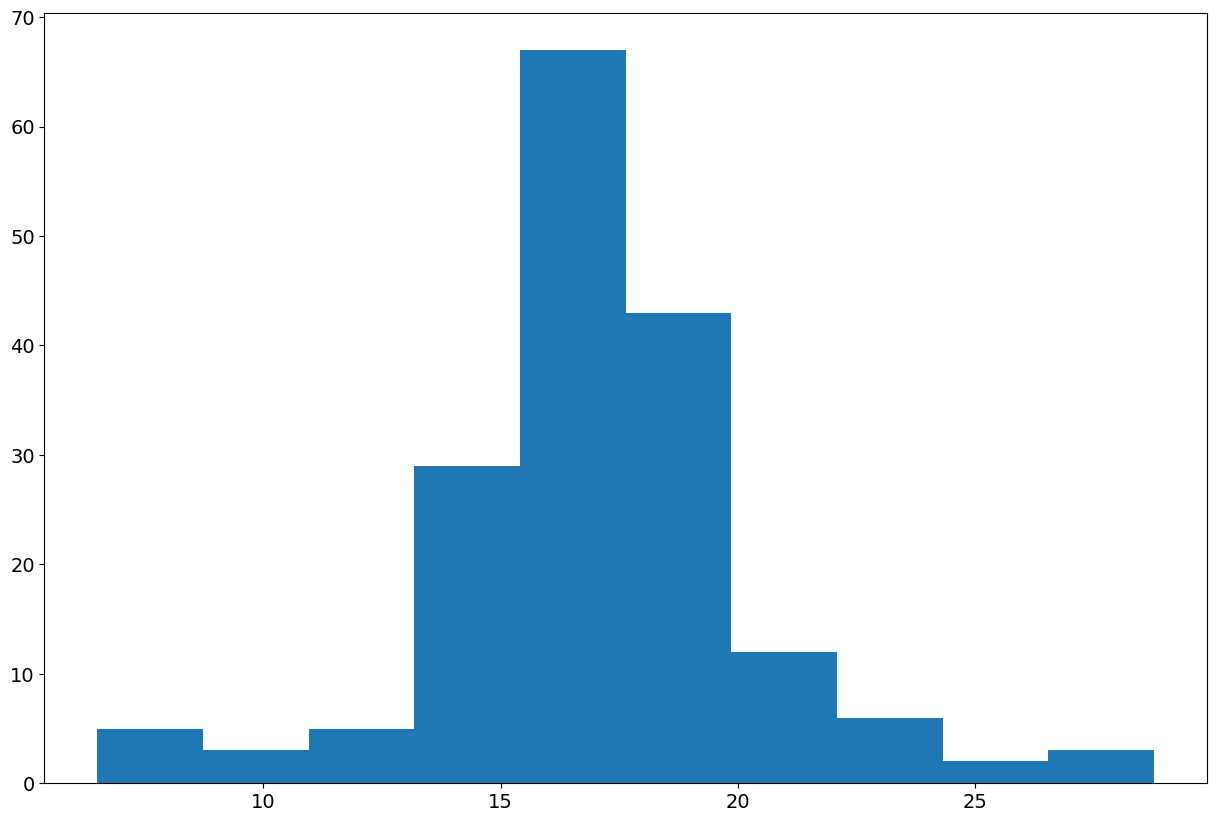

In [47]:
plt.hist(max_flux)

In [32]:
mjds = np.array([s["mjd"] for s in spectra])

In [43]:
mjds.shape

(175,)

In [39]:
max_flux = np.array(max_flux)

In [41]:
max_flux.shape

(175,)

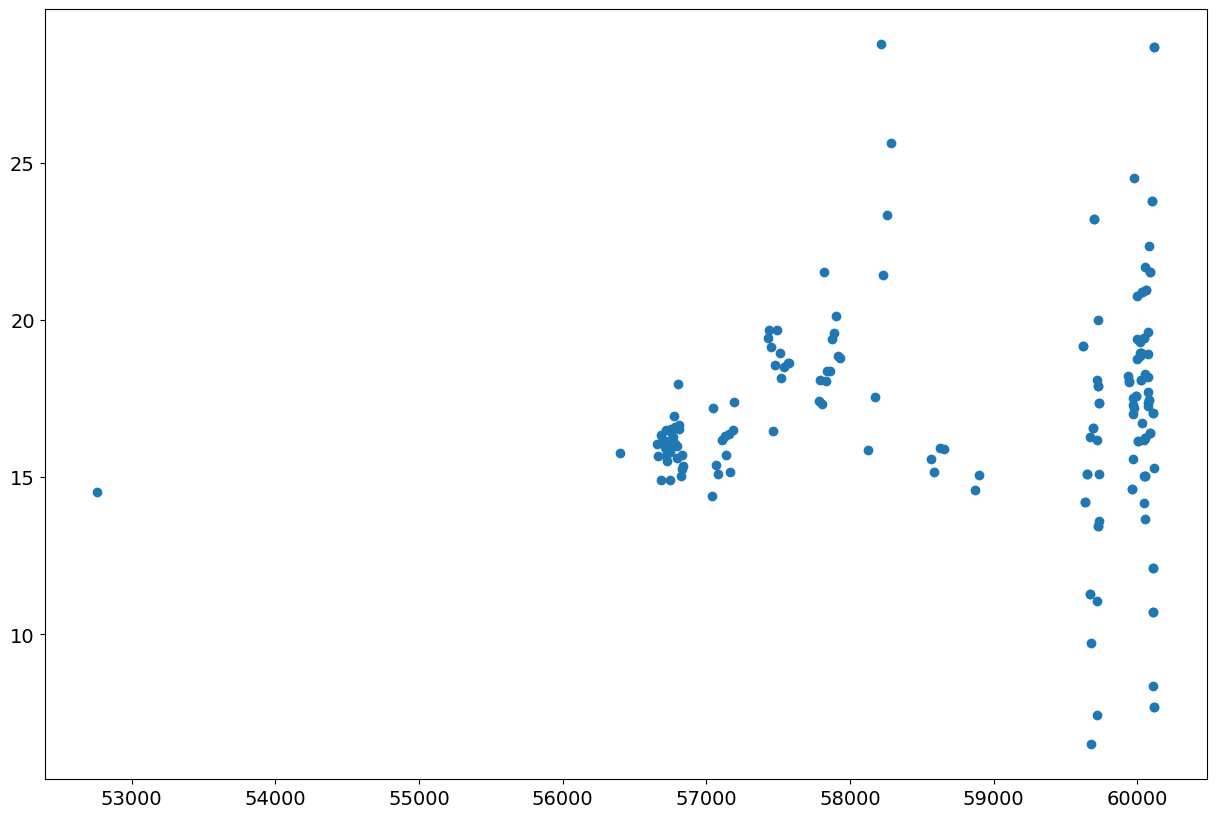

In [45]:
plt.scatter(mjds, max_flux)

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Define the model function: A*sin(B*x + C) + D
# A=amplitude, B=frequency, C=phase shift, D=vertical offset
def sine_func(x, A, B, C, D):
    return A * np.sin(B * x + C) + D

# 2. Example: Generate noisy data
y_data = 3.0 * np.sin(1.5 * max_flux + 0.5) + 2.0 + np.random.normal(size=175)

# 3. Provide initial guesses (p0) - CRITICAL for sine waves
# Guessing: Amplitude ~ std*2, Frequency ~ 1, Phase ~ 0, Offset ~ mean
guess = [np.std(y_data) * 2**0.5, 1.0, 0.0, np.mean(y_data)]

# 4. Perform the fit
params, covariance = curve_fit(sine_func, max_flux, y_data, p0=guess)

# result: [A, B, C, D]
A_fit, B_fit, C_fit, D_fit = params

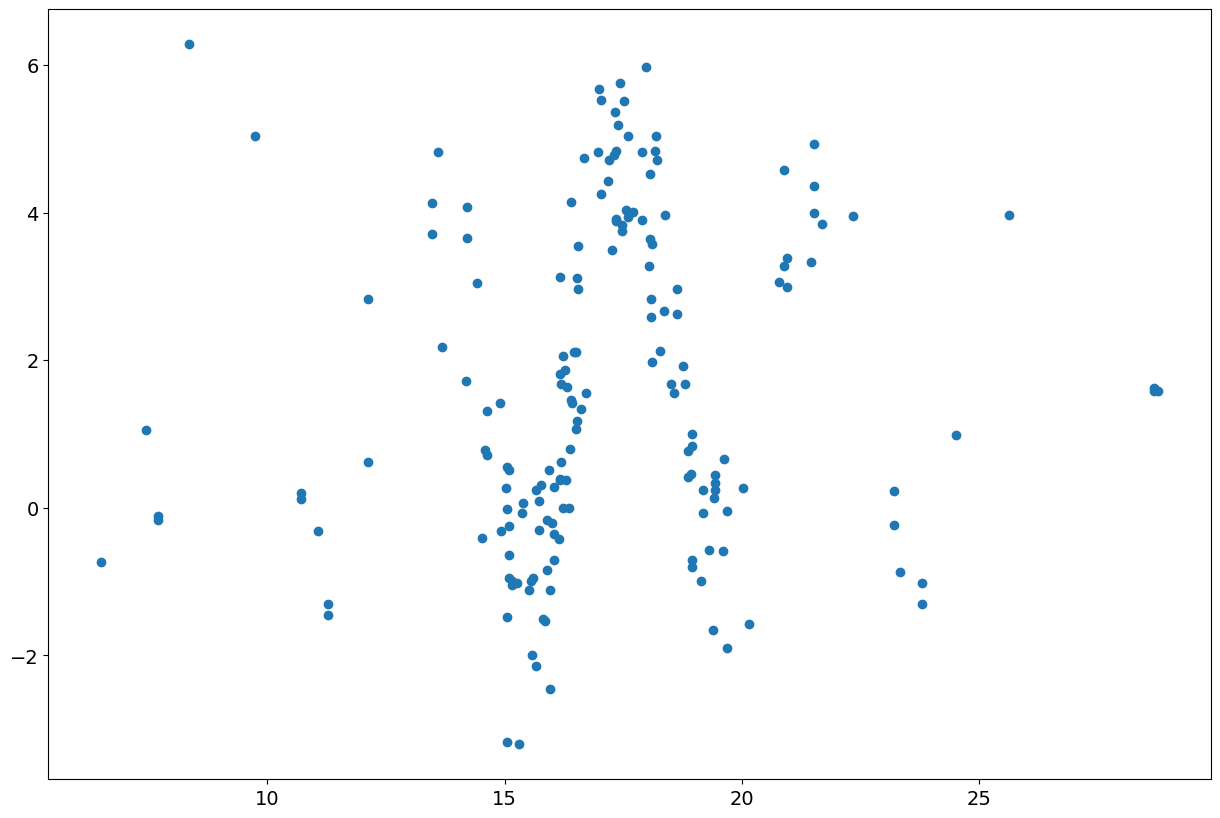

In [56]:
plt.scatter(max_flux, y_data)

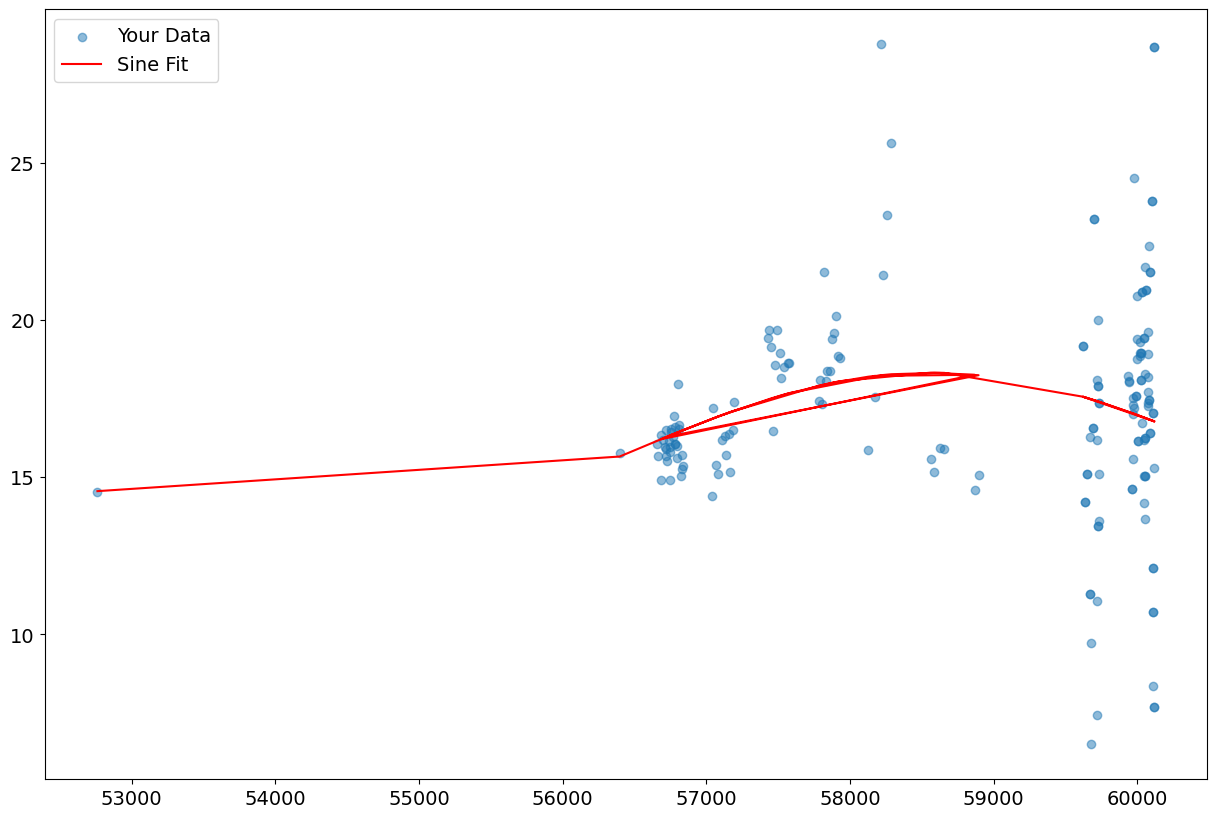

Calculated Period: 8543.69


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def fit_sine(x, y):
    # 1. Define the sine model: y = A * sin(B*x + C) + D
    def sine_func(x, a, b, c, d):
        return a * np.sin(b * x + c) + d

    # 2. Automated Initial Guesses
    # d_guess: The average level of the data
    d_guess = np.mean(y)
    # a_guess: Rough amplitude (standard deviation * sqrt(2))
    a_guess = np.std(y) * np.sqrt(2)
    # b_guess: Use Fast Fourier Transform (FFT) to find the dominant frequency
    # This prevents the fit from getting "stuck" on a local minimum.
    yf = np.fft.fft(y - d_guess)
    xf = np.fft.fftfreq(len(x), d=(x[1] - x[0]))
    b_guess = abs(xf[np.argmax(np.abs(yf))]) * 2 * np.pi

    p0 = [a_guess, b_guess, 0, d_guess]

    # 3. Perform the fit
    popt, _ = curve_fit(sine_func, x, y, p0=p0)
    return popt, sine_func

# Usage with your data (assuming x_data and y_data are numpy arrays)
params, model_func = fit_sine(mjds, max_flux)
a, b, c, d = params

# 4. Visualize to check the "fit"
plt.scatter(mjds, max_flux, label="Your Data", alpha=0.5)
plt.plot(mjds, model_func(mjds, *params), color='red', label="Sine Fit")
plt.legend()
plt.show()

print(f"Calculated Period: {2 * np.pi / b:.2f}")

In [ ]:
print(params)

In [66]:
mjds2 = np.delete(mjds, 0)
max_flux2 = np.delete(max_flux, 0)
max_flux3 = np.log(max_flux)

In [67]:
max_flux3

array([2.67552  , 2.757493 , 2.7753472, 2.751458 , 2.7518868, 2.7704263,
       2.66823  , 2.8450007, 2.7335694, 2.791926 , 2.7550418, 2.796438 ,
       2.718263 , 2.8577921, 2.8944983, 2.852428 , 3.0689657, 2.8939524,
       2.9109788, 2.9106026, 2.9643092, 2.7631767, 2.8652651, 2.6797845,
       2.703181 , 2.7944145, 2.78418  , 2.7694945, 2.804274 , 2.7653842,
       2.7818186, 2.7017965, 2.7601113, 2.8048134, 2.7987242, 2.7905068,
       2.8308191, 2.7755773, 2.8097832, 2.775619 , 2.7722669, 2.747484 ,
       2.8890343, 2.8132453, 2.8048618, 2.7143786, 2.967148 , 2.9795504,
       2.9521167, 2.8012872, 2.9209993, 2.9797535, 2.941351 , 2.8995981,
       2.9178286, 2.975041 , 3.0026274, 2.937523 , 2.9335198, 2.7455716,
       2.7188606, 2.711921 , 2.7413983, 2.7101164, 2.7548437, 2.724858 ,
       2.7325087, 2.7830427, 2.8033218, 2.8563607, 2.9253478, 2.9250839,
       3.359079 , 3.0654   , 3.1497653, 3.2433777, 2.7686112, 2.7660384,
       2.9536154, 2.6539986, 2.7145617, 2.423111 , 

In [64]:
max_flux2

array([15.7602825, 16.044199 , 15.665455 , 15.672176 , 15.965437 ,
       14.414433 , 17.201572 , 15.3877125, 16.312407 , 15.721698 ,
       16.386175 , 15.1539755, 17.423018 , 18.07443  , 17.329805 ,
       21.519632 , 18.064566 , 18.374773 , 18.367863 , 19.38131  ,
       15.850114 , 17.553705 , 14.581952 , 14.927141 , 16.353052 ,
       16.186537 , 15.950569 , 16.515081 , 15.88514  , 16.148361 ,
       14.906487 , 15.801601 , 16.523993 , 16.42368  , 16.289274 ,
       16.959347 , 16.04789  , 16.606318 , 16.04856  , 15.994851 ,
       15.603324 , 17.97594  , 16.663912 , 16.524792 , 15.095225 ,
       19.436407 , 19.678967 , 19.14644  , 16.465826 , 18.559824 ,
       19.682964 , 18.941416 , 18.166842 , 18.501068 , 19.590424 ,
       20.13838  , 18.869047 , 18.793667 , 15.573515 , 15.163037 ,
       15.058174 , 15.5086565, 15.031025 , 15.718584 , 15.254249 ,
       15.371401 , 16.168142 , 16.499365 , 17.398092 , 18.640709 ,
       18.63579  , 28.762682 , 21.443033 , 23.330587 , 25.6201

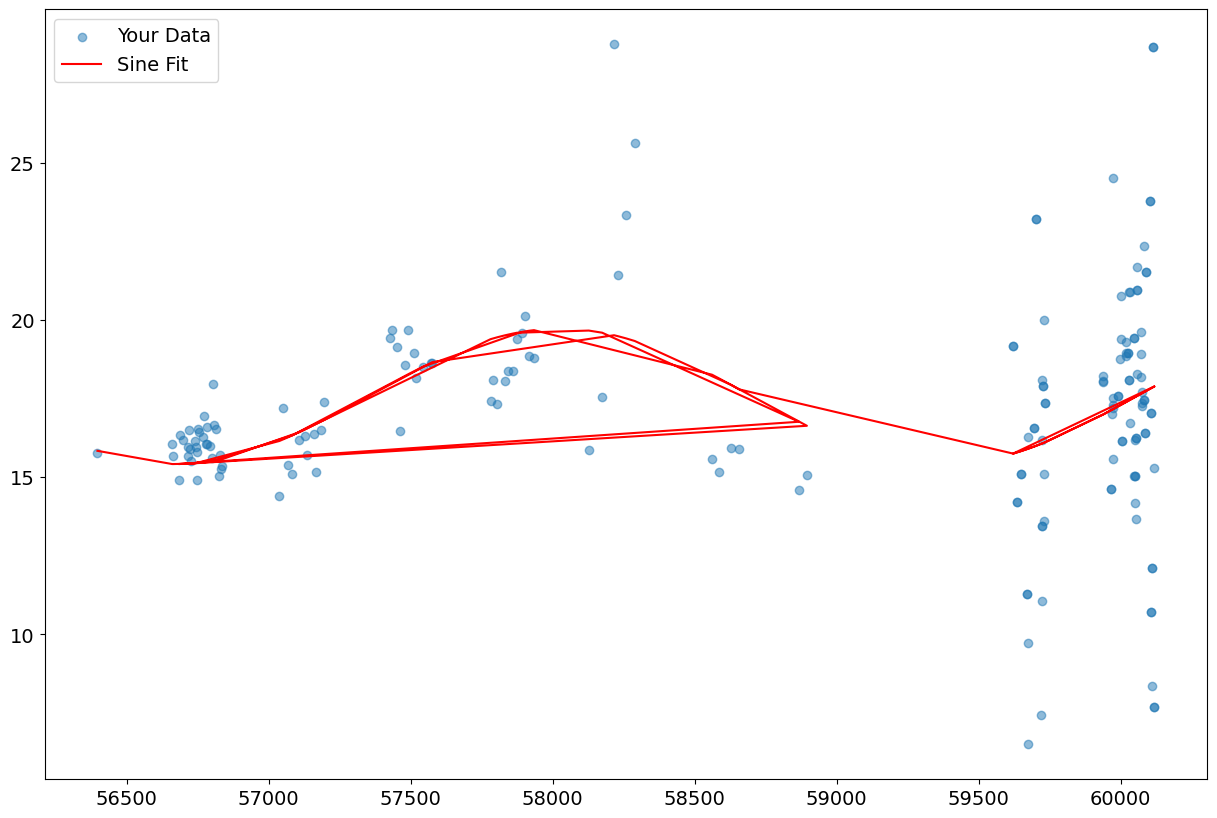

Calculated Period: 2707.14


In [65]:
params, model_func = fit_sine(mjds2, max_flux2)
a, b, c, d = params

# 4. Visualize to check the "fit"
plt.scatter(mjds2, max_flux2, label="Your Data", alpha=0.5)
plt.plot(mjds2, model_func(mjds2, *params), color='red', label="Sine Fit")
plt.legend()
plt.show()

print(f"Calculated Period: {2 * np.pi / b:.2f}")